In [1]:
# Experiment: SMOTE from Scratch (Conceptually)

#Synthetic Minority Over-sampling Technique

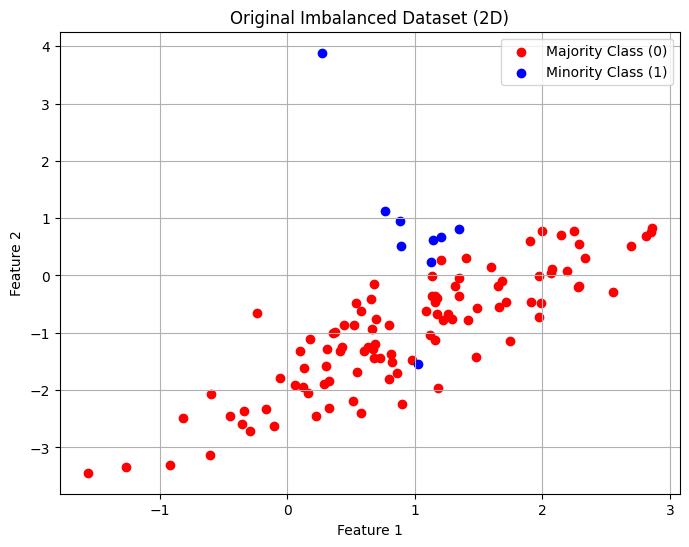

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import NearestNeighbors
X, y = make_classification(
    n_samples=110,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.91, 0.09],
    random_state=42
)

X_majority = X[y == 0]
X_minority = X[y == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_majority[:, 0], X_majority[:, 1], 
            color='red', label='Majority Class (0)')
plt.scatter(X_minority[:, 0], X_minority[:, 1], 
            color='blue', label='Minority Class (1)')

plt.title("Original Imbalanced Dataset (2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

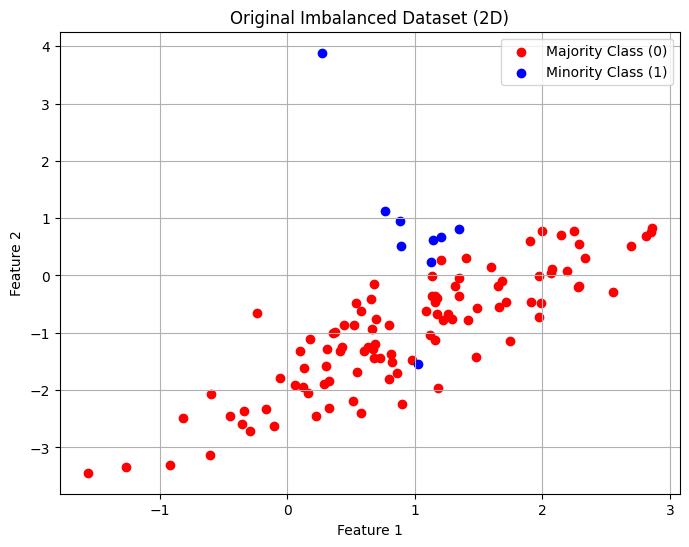

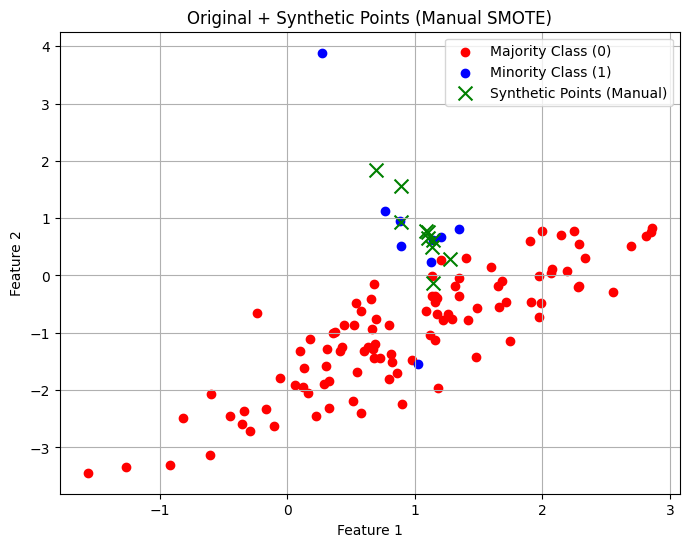

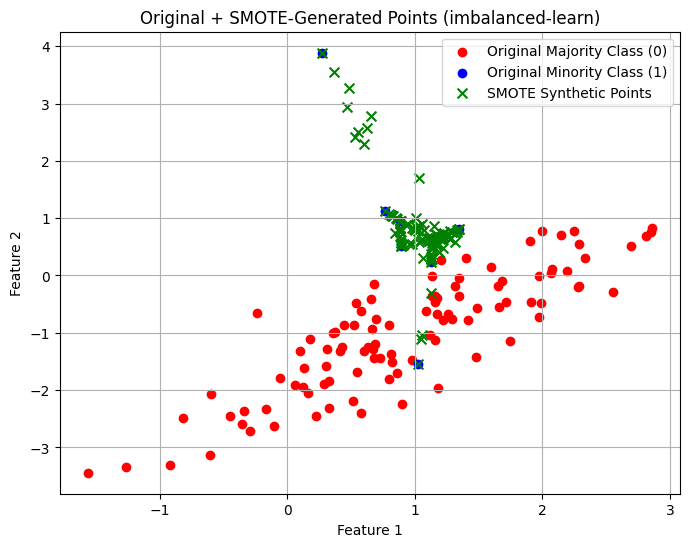

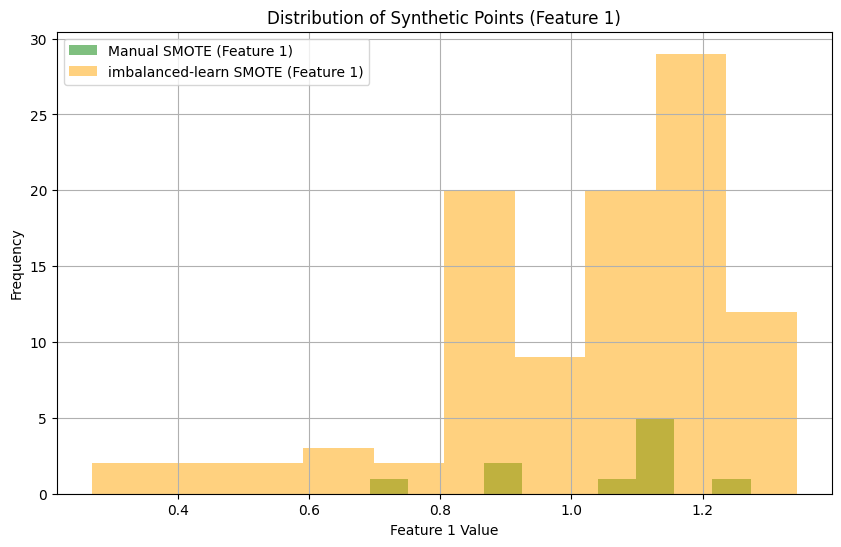

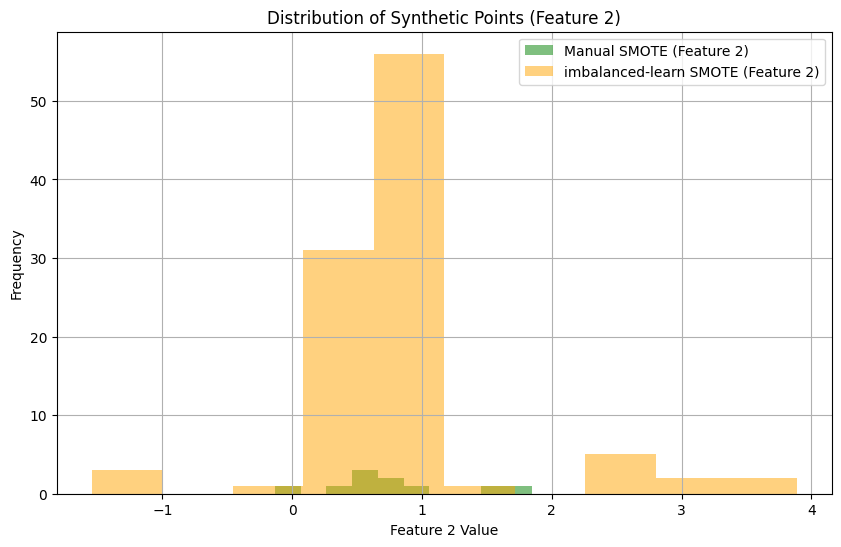

In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE

# Step 1: Create a synthetic imbalanced dataset (2D)
X, y = make_classification(
    n_samples=110,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.91, 0.09],
    random_state=42
)

# Separate majority and minority classes
X_majority = X[y == 0]
X_minority = X[y == 1]

# Plot original data
plt.figure(figsize=(8, 6))
plt.scatter(X_majority[:, 0], X_majority[:, 1], color='red', label='Majority Class (0)')
plt.scatter(X_minority[:, 0], X_minority[:, 1], color='blue', label='Minority Class (1)')
plt.title("Original Imbalanced Dataset (2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Step 2: Implement manual SMOTE
def manual_smote(X_minority, k=5, n_synthetic=10):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)
    distances, indices = nbrs.kneighbors(X_minority)
    X_synthetic = []
    for _ in range(n_synthetic):
        idx = np.random.randint(0, len(X_minority))
        sample = X_minority[idx]
        neighbor_idx = np.random.choice(indices[idx][1:])
        neighbor = X_minority[neighbor_idx]
        alpha = np.random.random()
        synthetic_point = sample + alpha * (neighbor - sample)
        X_synthetic.append(synthetic_point)
    return np.array(X_synthetic)

# Generate 10 synthetic points
X_synthetic = manual_smote(X_minority, k=5, n_synthetic=10)

# Plot original + synthetic points (manual SMOTE)
plt.figure(figsize=(8, 6))
plt.scatter(X_majority[:, 0], X_majority[:, 1], color='red', label='Majority Class (0)')
plt.scatter(X_minority[:, 0], X_minority[:, 1], color='blue', label='Minority Class (1)')
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], color='green', marker='x', s=100, label='Synthetic Points (Manual)')
plt.title("Original + Synthetic Points (Manual SMOTE)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Step 3: Use imbalanced-learn's SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_resampled_minority = X_resampled[y_resampled == 1]

# Plot original + SMOTE-generated points
plt.figure(figsize=(8, 6))
plt.scatter(X_majority[:, 0], X_majority[:, 1], color='red', label='Original Majority Class (0)')
plt.scatter(X_minority[:, 0], X_minority[:, 1], color='blue', label='Original Minority Class (1)')
plt.scatter(X_resampled_minority[:, 0], X_resampled_minority[:, 1], color='green', marker='x', s=50, label='SMOTE Synthetic Points')
plt.title("Original + SMOTE-Generated Points (imbalanced-learn)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Verify distributions
plt.figure(figsize=(10, 6))
plt.hist(X_synthetic[:, 0], bins=10, alpha=0.5, color='green', label='Manual SMOTE (Feature 1)')
plt.hist(X_resampled_minority[:, 0], bins=10, alpha=0.5, color='orange', label='imbalanced-learn SMOTE (Feature 1)')
plt.title("Distribution of Synthetic Points (Feature 1)")
plt.xlabel("Feature 1 Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(X_synthetic[:, 1], bins=10, alpha=0.5, color='green', label='Manual SMOTE (Feature 2)')
plt.hist(X_resampled_minority[:, 1], bins=10, alpha=0.5, color='orange', label='imbalanced-learn SMOTE (Feature 2)')
plt.title("Distribution of Synthetic Points (Feature 2)")
plt.xlabel("Feature 2 Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()